# Demand Forecasting for Inventory Planning — Superstore Sales

**Goal.** Build a unit-demand forecast that can inform inventory decisions
(stockouts vs. overstock), then compare two very different approaches on the
**same held-out period**:

1. **Part 1 — classical / ML survey with PyCaret 4.x**, then a *native*
   reimplementation of the winner (statsmodels / pmdarima), with residual
   diagnostics and prediction intervals.
2. **Part 2 — Google TimesFM 2.5** zero-shot foundation-model forecast
   (no gradient updates on this series; history is inference-time context).

**Business framing.** Inventory planning lives or dies on *units* over time,
not just revenue. Under-forecast → stockouts and lost sales; over-forecast →
excess inventory, cash tied up, and markdown risk. A useful forecast is
therefore (a) accurate on a time-ordered holdout and (b) honest about
uncertainty so you can set a safety buffer.

This notebook teaches the pipeline **newbie → pro**: raw transactions →
clean series → evidence-based aggregation → model survey → proper classical
fit → foundation-model zero-shot → fair metrics → inventory takeaway.

## 1. Setup

We pin a single `uv`-managed kernel (`demand-forecast-project`) for both
notebooks in this project. PyCaret **4.0** is OOP-only
(`TimeSeriesExperiment`); TimesFM **2.5** is loaded via `timesfm[torch]`.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import torch

try:
    from IPython import get_ipython
    from IPython.display import display

    IN_IPYTHON = get_ipython() is not None
except ImportError:  # plain script execution
    IN_IPYTHON = False

    def display(obj):
        print(obj)

import matplotlib

if not IN_IPYTHON:
    matplotlib.use("Agg")  # headless script runs only
import matplotlib.pyplot as plt


def show_plot() -> None:
    """Show in Jupyter (embed outputs); close in plain-script runs."""
    plt.tight_layout()
    if IN_IPYTHON:
        plt.show()
    else:
        plt.show(block=False)
        plt.close("all")
from pmdarima import auto_arima
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.titlesize"] = 12

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Python        : {sys.version.split()[0]}")
print(f"pandas        : {pd.__version__}")
print(f"numpy         : {np.__version__}")
print(f"torch         : {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")

import pycaret
import timesfm

print(f"pycaret       : {pycaret.__version__}")
print(f"timesfm 2.5   : TimesFM_2p5_200M_torch={hasattr(timesfm, 'TimesFM_2p5_200M_torch')}")
print(f"Kernel target : demand-forecast-project")
assert pycaret.__version__.startswith("4."), "Expected PyCaret 4.x OOP API"
assert hasattr(timesfm, "TimesFM_2p5_200M_torch"), "TimesFM 2.5 torch class missing"

Python        : 3.13.13
pandas        : 2.3.3
numpy         : 2.4.6
torch         : 2.13.0+cu130 | CUDA: True
GPU           : NVIDIA GeForce RTX 4060 Laptop GPU
pycaret       : 4.0.0a8
timesfm 2.5   : TimesFM_2p5_200M_torch=True
Kernel target : demand-forecast-project


## 2. Data acquisition — Superstore Sales

The classic Sample Superstore export: one row per line item with order dates,
categories, and **Quantity** (units). We load it live from GitHub so the
notebook is self-contained. Encoding note: the raw file ships with a UTF-8
BOM, so `utf-8-sig` is the right first try (latin-1 is a common fallback for
older Superstore copies).

In [2]:
PRIMARY_URL = (
    "https://raw.githubusercontent.com/yajasarora/"
    "Superstore-Sales-Analysis-with-Tableau/master/"
    "Superstore%20sales%20dataset.csv"
)
FALLBACK_URL = (
    "https://github.com/yajasarora/Superstore-Sales-Analysis-with-Tableau/"
    "raw/refs/heads/master/Superstore%20sales%20dataset.csv"
)

def load_superstore() -> pd.DataFrame:
    for url in (PRIMARY_URL, FALLBACK_URL):
        for enc in ("utf-8-sig", "latin-1"):
            try:
                frame = pd.read_csv(url, encoding=enc)
                print(f"Loaded via encoding={enc!r}\n  url={url}")
                return frame
            except Exception as exc:  # noqa: BLE001 — try next candidate
                print(f"Failed ({enc}): {type(exc).__name__}: {exc}")
    raise RuntimeError("Could not load Superstore CSV from either URL")

df_raw = load_superstore()
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
display(df_raw.head(3))
display(df_raw.dtypes.to_frame("dtype"))

Loaded via encoding='utf-8-sig'
  url=https://raw.githubusercontent.com/yajasarora/Superstore-Sales-Analysis-with-Tableau/master/Superstore%20sales%20dataset.csv
Shape: (9994, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


,dtype
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


## 3. Exploratory data analysis

Inventory forecasting needs a clean **unit demand** timeline. We inspect
missingness, quantity outliers, and the temporal span before choosing an
aggregation grain.

=== Missingness ===
Order Date    0
Quantity      0
dtype: int64

Date range: 2014-01-03 00:00:00 → 2017-12-30 00:00:00
Rows: 9,994
Duplicate Row ID: 0

=== Quantity distribution ===
count    9994.000000
mean        3.789574
std         2.225110
min         1.000000
1%          1.000000
50%         3.000000
99%        11.000000
max        14.000000
Name: Quantity, dtype: float64
Non-positive Quantity rows: 0
Null Order Date rows: 0

Kept 9,994 / 9,994 rows after date/quantity cleaning

Calendar days spanned: 1458
Days with zero orders: 221 (15.2%)
Mean orders/day: 6.85 | CV: 0.94


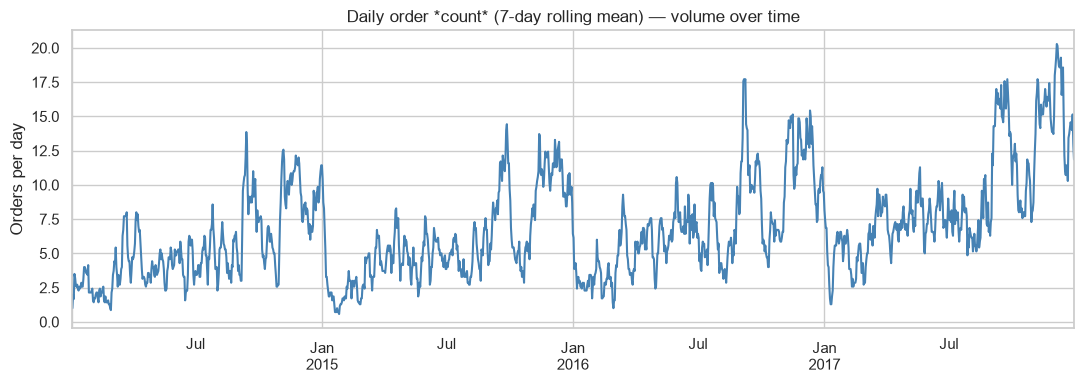

In [3]:
# Normalize column names that may have stray spaces
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

required = {"Order Date", "Quantity"}
missing_cols = required - set(df.columns)
if missing_cols:
    raise KeyError(f"Missing expected columns: {missing_cols}")

# This export mixes D/M/Y styles; dayfirst=True + coerce keeps all valid calendar dates.
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce", dayfirst=True)
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

print("=== Missingness ===")
print(df[["Order Date", "Quantity"]].isna().sum())
print(f"\nDate range: {df['Order Date'].min()} → {df['Order Date'].max()}")
print(f"Rows: {len(df):,}")
print(f"Duplicate Row ID: {df['Row ID'].duplicated().sum() if 'Row ID' in df.columns else 'n/a'}")

print("\n=== Quantity distribution ===")
print(df["Quantity"].describe(percentiles=[0.01, 0.5, 0.99]))
print(f"Non-positive Quantity rows: {(df['Quantity'] <= 0).sum()}")
print(f"Null Order Date rows: {df['Order Date'].isna().sum()}")

# Drop unusable rows for demand aggregation
n_before = len(df)
df = df.dropna(subset=["Order Date", "Quantity"])
df = df[df["Quantity"] > 0].copy()
print(f"\nKept {len(df):,} / {n_before:,} rows after date/quantity cleaning")

# Daily order counts (sparsity check)
daily_orders = df.groupby(df["Order Date"].dt.normalize()).size()
full_daily_idx = pd.date_range(daily_orders.index.min(), daily_orders.index.max(), freq="D")
daily_orders = daily_orders.reindex(full_daily_idx, fill_value=0)
print(f"\nCalendar days spanned: {len(daily_orders)}")
print(f"Days with zero orders: {(daily_orders == 0).sum()} "
      f"({100 * (daily_orders == 0).mean():.1f}%)")
print(f"Mean orders/day: {daily_orders.mean():.2f} | CV: {daily_orders.std()/daily_orders.mean():.2f}")

fig, ax = plt.subplots()
daily_orders.rolling(7, min_periods=1).mean().plot(ax=ax, color="steelblue")
ax.set_title("Daily order *count* (7-day rolling mean) — volume over time")
ax.set_ylabel("Orders per day")
show_plot()

### 3.1 Candidate granularities: daily vs weekly unit demand

Daily retail series are often sparse and noisy for *aggregate* planning.
We compare daily vs weekly **Quantity** sums with hard numbers, then pick
one grain for the rest of the notebook.

,grain,n,mean,std,cv,pct_zero,min,max,start,end
0,daily,1458,25.975995,25.436615,0.979235,15.15775,0.0,152.0,2014-01-03,2017-12-30
1,weekly,209,181.210526,102.462205,0.565432,0.00000,13.0,564.0,2014-01-05,2017-12-31


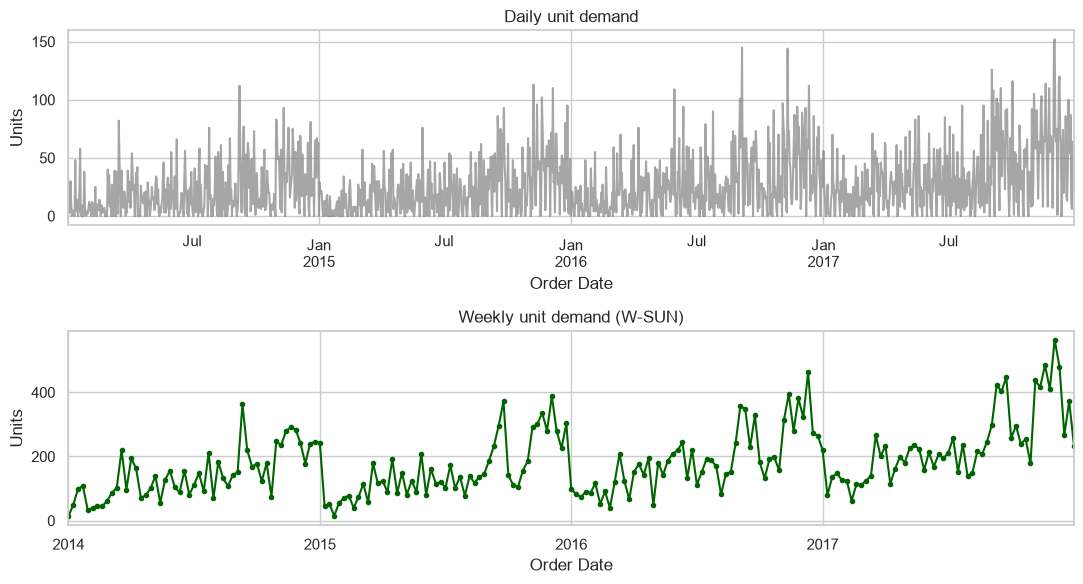


>>> GRANULARITY DECISION: WEEKLY
Daily series has 15.2% zero-demand days and CV=0.98 vs weekly CV=0.57. Weekly aggregation is more stable for inventory planning.
Series length: 209 | 2014-01-05 → 2017-12-31


In [4]:
demand_daily = (
    df.groupby(df["Order Date"].dt.normalize())["Quantity"]
    .sum()
    .rename("demand")
    .asfreq("D", fill_value=0)
    .sort_index()
)
demand_weekly = (
    df.set_index("Order Date")["Quantity"]
    .resample("W-SUN")
    .sum()
    .rename("demand")
    .sort_index()
)
# Drop leading/trailing partial zeros only at edges if empty — keep interior zeros
demand_weekly = demand_weekly.loc[demand_weekly.ne(0).idxmax() : demand_weekly.ne(0)[::-1].idxmax()]

def series_profile(s: pd.Series, name: str) -> dict:
    s = s.astype(float)
    prof = {
        "grain": name,
        "n": int(s.shape[0]),
        "mean": float(s.mean()),
        "std": float(s.std(ddof=1)),
        "cv": float(s.std(ddof=1) / s.mean()) if s.mean() else np.nan,
        "pct_zero": float((s == 0).mean() * 100),
        "min": float(s.min()),
        "max": float(s.max()),
        "start": str(s.index.min().date()),
        "end": str(s.index.max().date()),
    }
    return prof

profiles = pd.DataFrame([
    series_profile(demand_daily, "daily"),
    series_profile(demand_weekly, "weekly"),
])
display(profiles)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=False)
demand_daily.plot(ax=axes[0], color="gray", alpha=0.7, title="Daily unit demand")
axes[0].set_ylabel("Units")
demand_weekly.plot(ax=axes[1], color="darkgreen", marker="o", ms=3, title="Weekly unit demand (W-SUN)")
axes[1].set_ylabel("Units")
show_plot()

# Decision rule: prefer weekly if daily has high zero share or much higher CV
daily_pct_zero = profiles.loc[profiles.grain == "daily", "pct_zero"].iloc[0]
daily_cv = profiles.loc[profiles.grain == "daily", "cv"].iloc[0]
weekly_cv = profiles.loc[profiles.grain == "weekly", "cv"].iloc[0]

if daily_pct_zero > 15 or daily_cv > weekly_cv * 1.15:
    GRAIN = "weekly"
    y_full = demand_weekly.copy()
    SEASONAL_PERIOD = 52  # annual seasonality on weekly data (if history allows)
    FREQ = "W-SUN"
    decision_reason = (
        f"Daily series has {daily_pct_zero:.1f}% zero-demand days and CV={daily_cv:.2f} "
        f"vs weekly CV={weekly_cv:.2f}. Weekly aggregation is more stable for inventory planning."
    )
else:
    GRAIN = "daily"
    y_full = demand_daily.copy()
    SEASONAL_PERIOD = 7
    FREQ = "D"
    decision_reason = (
        f"Daily series is dense enough (zero days={daily_pct_zero:.1f}%, CV={daily_cv:.2f}); "
        "keeping daily grain for finer-grained planning."
    )

print(f"\n>>> GRANULARITY DECISION: {GRAIN.upper()}")
print(decision_reason)
print(f"Series length: {len(y_full)} | {y_full.index.min().date()} → {y_full.index.max().date()}")

### 3.2 Trend, seasonality, stationarity on the chosen series

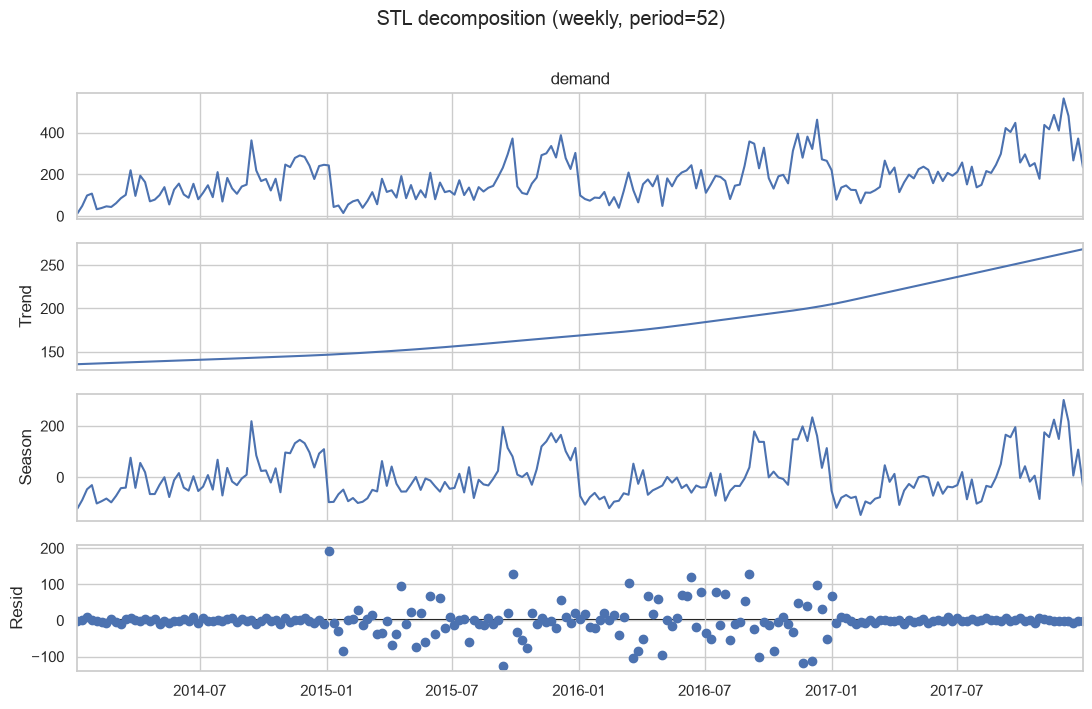

ADF statistic=-4.1662, p-value=0.0007514
Reject H0 of unit root → series looks stationary (at 5%).


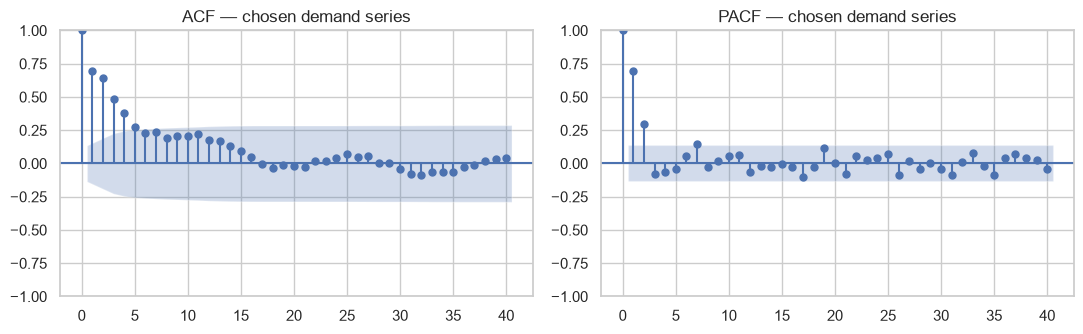


Units by Category (full history):


,units
Category,
Office Supplies,22906
Furniture,8028
Technology,6939


Units by Region (full history):


,units
Region,
West,12266
East,10618
Central,8780
South,6209


In [5]:
# STL needs a consistent period that fits the sample length
stl_period = SEASONAL_PERIOD
if len(y_full) < 2 * stl_period + 1:
    stl_period = 7 if GRAIN == "weekly" else 7
    print(f"Series shorter than 2×{SEASONAL_PERIOD}; using STL period={stl_period}")

stl = STL(y_full.astype(float), period=stl_period, robust=True)
stl_res = stl.fit()

fig = stl_res.plot()
fig.set_size_inches(11, 7)
fig.suptitle(f"STL decomposition ({GRAIN}, period={stl_period})", y=1.01)
show_plot()

adf_stat, adf_p, *_ = adfuller(y_full.astype(float), autolag="AIC")
print(f"ADF statistic={adf_stat:.4f}, p-value={adf_p:.4g}")
if adf_p < 0.05:
    print("Reject H0 of unit root → series looks stationary (at 5%).")
else:
    print("Fail to reject unit root → trend/integration may be present; ARIMA-style differencing helps.")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
plot_acf(y_full.astype(float), lags=min(40, len(y_full) // 2 - 1), ax=axes[0])
plot_pacf(y_full.astype(float), lags=min(40, len(y_full) // 2 - 1), ax=axes[1], method="ywm")
axes[0].set_title("ACF — chosen demand series")
axes[1].set_title("PACF — chosen demand series")
show_plot()

# Light business breakdown (context only — forecast remains total units)
if "Category" in df.columns:
    by_cat = df.groupby("Category")["Quantity"].sum().sort_values(ascending=False)
    print("\nUnits by Category (full history):")
    display(by_cat.to_frame("units"))
if "Region" in df.columns:
    by_reg = df.groupby("Region")["Quantity"].sum().sort_values(ascending=False)
    print("Units by Region (full history):")
    display(by_reg.to_frame("units"))

## 4. Target series + time-ordered holdout

**No random shuffle.** The last `H` periods are the test set; everything
before is train / TimesFM context. The same `H` is used for PyCaret's
forecast horizon and TimesFM's `horizon`.

Grain=weekly | H=8 | seasonal_period candidate=52
Train: 2014-01-05 → 2017-11-05 (n=201)
Test : 2017-11-12 → 2017-12-31 (n=8)
Train mean demand: 172.4 units / period
Test  mean demand: 403.4 units / period


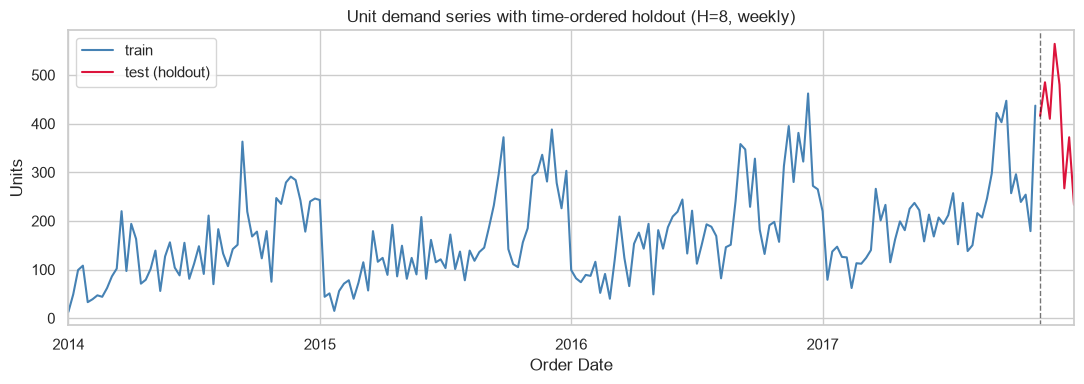

In [6]:
# Holdout: 8 weeks or ~28 days, but keep train reasonably long
if GRAIN == "weekly":
    H = 8
else:
    H = 28

if len(y_full) <= H + 20:
    H = max(4, len(y_full) // 5)
    print(f"Short series — reducing H to {H}")

y = y_full.astype(float).copy()
y.name = "demand"
y_train = y.iloc[:-H]
y_test = y.iloc[-H:]

print(f"Grain={GRAIN} | H={H} | seasonal_period candidate={SEASONAL_PERIOD}")
print(f"Train: {y_train.index.min().date()} → {y_train.index.max().date()} (n={len(y_train)})")
print(f"Test : {y_test.index.min().date()} → {y_test.index.max().date()} (n={len(y_test)})")
print(f"Train mean demand: {y_train.mean():.1f} units / period")
print(f"Test  mean demand: {y_test.mean():.1f} units / period")

fig, ax = plt.subplots()
y_train.plot(ax=ax, label="train", color="steelblue")
y_test.plot(ax=ax, label="test (holdout)", color="crimson")
ax.axvline(y_test.index[0], color="k", ls="--", lw=1, alpha=0.6)
ax.set_title(f"Unit demand series with time-ordered holdout (H={H}, {GRAIN})")
ax.set_ylabel("Units")
ax.legend()
show_plot()

In [7]:
def forecast_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_train_arr: np.ndarray, m: int) -> dict:
    """MAE, RMSE, MAPE (epsilon-safe), MASE (seasonal naive scale)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train_arr = np.asarray(y_train_arr, dtype=float)
    err = y_true - y_pred
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    denom = np.maximum(np.abs(y_true), 1e-8)
    mape = float(np.mean(np.abs(err) / denom) * 100)
    m = max(1, min(m, len(y_train_arr) // 2))
    scale = np.mean(np.abs(y_train_arr[m:] - y_train_arr[:-m]))
    if not np.isfinite(scale) or scale < 1e-8:
        scale = np.mean(np.abs(np.diff(y_train_arr))) + 1e-8
    mase = float(mae / scale)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "MASE": mase}

## 5. Part 1 — PyCaret time-series survey (MASE-ranked)

PyCaret 4.x uses an **experiment class**, not the old free functions
(`setup` / `compare_models` as bare imports). Pattern:

```python
exp = TimeSeriesExperiment(fh=H, session_id=42)
exp.fit(y_train)                 # univariate Series
result = exp.compare_models(sort="MASE")
# result.best, result.leaderboard, result.ranked_ids
```

We fit on **train only** so the holdout stays untouched. `sort="MASE"` is
scale-independent and is PyCaret's recommended cross-series metric.

In [8]:
from pycaret.time_series import TimeSeriesExperiment

# Seasonal period for model selection:
# Full annual weekly seasonality (52) makes auto_arima/ETS extremely slow on ~200 points.
# Use a practical short cycle for the survey (monthly-ish weeks=4; daily=7).
if GRAIN == "weekly":
    sp_for_exp = 4
else:
    sp_for_exp = 7
if len(y_train) < 2 * sp_for_exp:
    sp_for_exp = max(1, len(y_train) // 4)
print(
    f"PyCaret seasonal_period={sp_for_exp} "
    f"(STL/ACF still used period≈{SEASONAL_PERIOD} for EDA; survey uses a faster cycle)"
)

exp = TimeSeriesExperiment(
    fh=H,
    session_id=SEED,
    fold=2,
    fold_strategy="expanding",
    seasonal_period=sp_for_exp,
    verbose=False,
    n_jobs=1,
)
exp.fit(y_train)

print("Registered turbo-eligible models (sample):")
try:
    model_table = exp.models()
    display(model_table)
except Exception as exc:  # noqa: BLE001
    print("models() unavailable:", exc)

# Focus the survey on classical families (fast + natively re-implementable).
# turbo=True alone still tries many ML-reduction models and can take a long time.
# auto_arima omitted from the survey for runtime; re-added only if we need a
# broader search. Classical set still covers ARIMA/ETS/Theta/naive baselines.
SURVEY_INCLUDE = [
    "naive",
    "snaive",
    "grand_means",
    "polytrend",
    "arima",
    "exp_smooth",
    "ets",
    "theta",
    "croston",
]
print(f"\nRunning compare_models(sort='MASE', include={SURVEY_INCLUDE})…")
compare_result = exp.compare_models(
    sort="MASE",
    include=SURVEY_INCLUDE,
    turbo=True,
    n_select=1,
    verbose=False,
)

leaderboard = compare_result.leaderboard.copy()
# Drop rows where MASE failed entirely
if "MASE" in leaderboard.columns:
    leaderboard_valid = leaderboard.dropna(subset=["MASE"]).reset_index(drop=True)
else:
    leaderboard_valid = leaderboard

print("\n=== PyCaret leaderboard (MASE-sorted; lower is better) ===")
display(leaderboard_valid)

if leaderboard_valid.empty or compare_result.best is None:
    raise RuntimeError(
        "PyCaret compare_models returned no successful models. "
        f"Raw leaderboard:\n{leaderboard}"
    )

winner_id = str(compare_result.ranked_ids[0])
winner_row = leaderboard_valid.iloc[0]
print(f"\n>>> PYCARET WINNER: {winner_id}")
print(winner_row.to_string())

PyCaret seasonal_period=4 (STL/ACF still used period≈52 for EDA; survey uses a faster cycle)


Registered turbo-eligible models (sample):


,Name,Reference,Turbo
ID,,,
naive,Naive Forecaster,sktime.forecasting.naive._naive.NaiveForecaster,True
grand_means,Grand Means Forecaster,sktime.forecasting.naive._naive.NaiveForecaster,True
snaive,Seasonal Naive Forecaster,sktime.forecasting.naive._naive.NaiveForecaster,True
polytrend,Polynomial Trend Forecaster,sktime.forecasting.trend._polynomial_trend_for...,True
arima,ARIMA,sktime.forecasting.arima._pmdarima.ARIMA,True
auto_arima,Auto ARIMA,sktime.forecasting.arima._pmdarima.AutoARIMA,True
exp_smooth,Exponential Smoothing,sktime.forecasting.exp_smoothing.ExponentialSm...,True
ets,ETS,sktime.forecasting.ets.AutoETS,True
theta,Theta Forecaster,sktime.forecasting.theta.ThetaForecaster,True



Running compare_models(sort='MASE', include=['naive', 'snaive', 'grand_means', 'polytrend', 'arima', 'exp_smooth', 'ets', 'theta', 'croston'])…



=== PyCaret leaderboard (MASE-sorted; lower is better) ===


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,COVERAGE
0,ets,0.7146,0.5981,55.3460,62.4106,0.2724,0.3221,-2.9130,0.8125
1,arima,1.3682,1.1536,105.6217,120.1685,0.5181,0.7900,-10.7881,1.0000
2,snaive,1.7884,1.4368,138.0570,149.6472,0.6829,1.0948,-16.9761,1.0000
3,grand_means,2.3880,1.8162,184.3056,189.0911,0.8958,1.6245,-26.3902,1.0000
4,naive,2.6953,2.2244,208.1506,231.6494,0.9768,1.5555,-41.3092,1.0000



>>> PYCARET WINNER: ets
Model           ets
MASE         0.7146
RMSSE        0.5981
MAE          55.346
RMSE        62.4106
MAPE         0.2724
SMAPE        0.3221
R2           -2.913
COVERAGE     0.8125


## 6. Part 1b — Native reimplementation of the survey winner

PyCaret's job was **model selection**. We now re-fit the winning family with
its native library (pmdarima / statsmodels), inspect residuals (ACF/PACF +
Ljung-Box), and produce a forecast with prediction intervals on the holdout.

Native model: statsmodels ExponentialSmoothing (seasonal=True)
Holdout point forecast (first 5): [346.3, 338.2, 347.8, 348.2, 352.4]


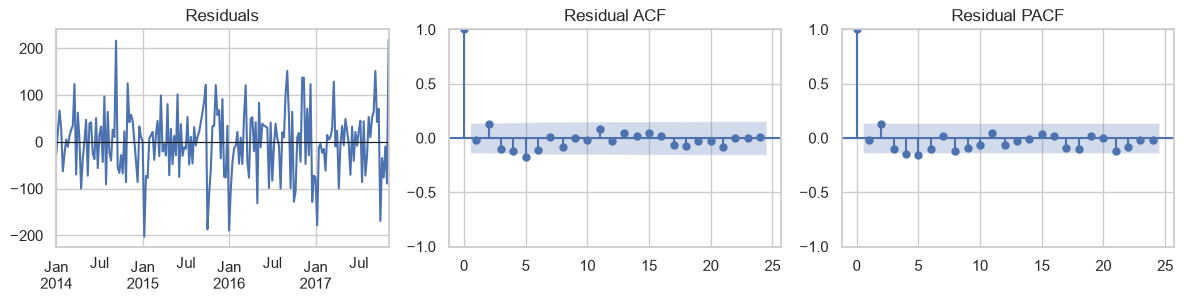

Ljung-Box on residuals (H0: no residual autocorrelation):


,lb_stat,lb_pvalue
10,19.568267,0.033611


p=0.0336 → residual structure remains; model may be under-specified.


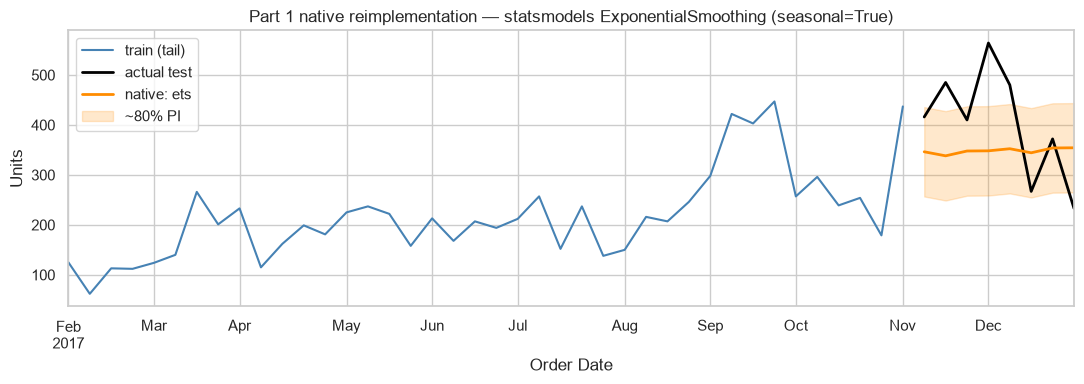

Native holdout metrics: {'MAE': 104.8437, 'RMSE': 119.4498, 'MAPE': 26.6113, 'MASE': 1.3164}


In [9]:
def fit_native_winner(
    model_id: str,
    train: pd.Series,
    h: int,
    seasonal_period: int,
):
    """Map PyCaret model id → native fit; return pred, lower, upper, residuals, label."""
    mid = model_id.lower()
    train_vals = train.astype(float)
    index_future = train.index[-1]  # unused; we align to y_test index later
    residuals = None
    label = model_id

    # --- classical families ---
    if mid in {"auto_arima", "arima"}:
        sp = seasonal_period if len(train_vals) >= 2 * seasonal_period else 1
        seasonal = sp > 1
        model = auto_arima(
            train_vals,
            seasonal=seasonal,
            m=sp if seasonal else 1,
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore",
            trace=False,
            random_state=SEED,
            n_jobs=1,
        )
        fc = model.predict(n_periods=h, return_conf_int=True, alpha=0.2)
        pred = np.asarray(fc[0], dtype=float)
        lower = np.asarray(fc[1][:, 0], dtype=float)
        upper = np.asarray(fc[1][:, 1], dtype=float)
        residuals = pd.Series(model.resid(), index=train_vals.index[-len(model.resid()) :])
        label = f"pmdarima auto_arima {model.order} seasonal={model.seasonal_order}"
        return pred, lower, upper, residuals, label, model

    if mid in {"exp_smooth", "ets"}:
        # Holt-Winters: use additive trend; seasonality if enough history
        use_seasonal = len(train_vals) >= 2 * seasonal_period and seasonal_period > 1
        hw = ExponentialSmoothing(
            train_vals,
            trend="add",
            seasonal="add" if use_seasonal else None,
            seasonal_periods=seasonal_period if use_seasonal else None,
            initialization_method="estimated",
        ).fit(optimized=True)
        pred = np.asarray(hw.forecast(h), dtype=float)
        # Approximate PI from residual std (ETS forecast se not always available)
        resid = train_vals - hw.fittedvalues
        resid = resid.dropna()
        sigma = float(resid.std(ddof=1)) if len(resid) else 1.0
        z = stats.norm.ppf(0.9)  # ~80% central interval
        lower = pred - z * sigma
        upper = pred + z * sigma
        residuals = resid
        label = f"statsmodels ExponentialSmoothing (seasonal={use_seasonal})"
        return pred, lower, upper, residuals, label, hw

    if mid == "theta":
        # Simple Theta-like: SES on seasonally adjusted + drift (Hyndman-style lite)
        # Fallback: ETS additive with no seasonal component + linear drift
        hw = ExponentialSmoothing(
            train_vals, trend="add", seasonal=None, initialization_method="estimated"
        ).fit(optimized=True)
        pred = np.asarray(hw.forecast(h), dtype=float)
        resid = (train_vals - hw.fittedvalues).dropna()
        sigma = float(resid.std(ddof=1)) if len(resid) else 1.0
        z = stats.norm.ppf(0.9)
        residuals = resid
        label = "Theta-analogue via additive Holt (statsmodels)"
        return pred, pred - z * sigma, pred + z * sigma, residuals, label, hw

    if mid == "naive":
        last = float(train_vals.iloc[-1])
        pred = np.full(h, last)
        resid = train_vals.diff().dropna()
        sigma = float(resid.std(ddof=1)) if len(resid) else 1.0
        z = stats.norm.ppf(0.9)
        residuals = resid
        label = "Naive (last value)"
        return pred, pred - z * sigma, pred + z * sigma, residuals, label, None

    if mid == "snaive":
        sp = seasonal_period if seasonal_period > 1 else 7
        if len(train_vals) < sp:
            sp = max(1, len(train_vals) // 2)
        hist = train_vals.values
        pred = np.array([hist[-sp + (i % sp)] for i in range(h)], dtype=float)
        # residual from one-step seasonal naive on train
        if len(hist) > sp:
            fitted = hist[:-sp]
            actual = hist[sp:]
            resid = pd.Series(actual - fitted)
        else:
            resid = train_vals.diff().dropna()
        sigma = float(resid.std(ddof=1)) if len(resid) else 1.0
        z = stats.norm.ppf(0.9)
        residuals = resid
        label = f"Seasonal naive (period={sp})"
        return pred, pred - z * sigma, pred + z * sigma, residuals, label, None

    if mid in {"grand_means", "polytrend"}:
        if mid == "grand_means":
            level = float(train_vals.mean())
            pred = np.full(h, level)
            fitted = pd.Series(level, index=train_vals.index)
            label = "Grand mean"
        else:
            x = np.arange(len(train_vals))
            coef = np.polyfit(x, train_vals.values, deg=1)
            pred = np.polyval(coef, np.arange(len(train_vals), len(train_vals) + h))
            fitted = pd.Series(np.polyval(coef, x), index=train_vals.index)
            label = "Linear trend (poly deg=1)"
        resid = (train_vals - fitted).dropna()
        sigma = float(resid.std(ddof=1)) if len(resid) else 1.0
        z = stats.norm.ppf(0.9)
        residuals = resid
        return pred, pred - z * sigma, pred + z * sigma, residuals, label, None

    if mid == "croston":
        # Croston-ish for intermittent demand: simple SES on non-zero demand + interval
        # Practical fallback: auto_arima
        print(f"Native Croston not implemented; falling back to pmdarima for id={mid}")
        return fit_native_winner("auto_arima", train, h, seasonal_period)

    # ML reduction models (*_cds_dt) or unknown → pmdarima with explicit note
    print(
        f"Winner '{model_id}' is not a pure classical family with a short native "
        "reimplementation path in this tutorial. Re-fitting with pmdarima auto_arima "
        "as the classical counterpart (documented mapping)."
    )
    pred, lower, upper, residuals, label, model = fit_native_winner(
        "auto_arima", train, h, seasonal_period
    )
    label = f"mapped({model_id})→{label}"
    return pred, lower, upper, residuals, label, model


native_pred, native_lo, native_hi, native_resid, native_label, native_model = fit_native_winner(
    winner_id, y_train, H, sp_for_exp
)
# Align to test index; clip negative unit forecasts at 0 for inventory sense
native_fc = pd.Series(np.clip(native_pred, 0, None), index=y_test.index, name="native_forecast")
native_lo_s = pd.Series(native_lo, index=y_test.index)
native_hi_s = pd.Series(native_hi, index=y_test.index)

print(f"Native model: {native_label}")
print(f"Holdout point forecast (first 5): {native_fc.head().round(1).tolist()}")

# Residual diagnostics
if native_resid is not None and len(native_resid.dropna()) > 10:
    resid = native_resid.dropna()
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
    resid.plot(ax=axes[0], title="Residuals")
    axes[0].axhline(0, color="k", lw=0.8)
    plot_acf(resid, lags=min(24, len(resid) // 2 - 1), ax=axes[1])
    plot_pacf(resid, lags=min(24, len(resid) // 2 - 1), ax=axes[2], method="ywm")
    axes[1].set_title("Residual ACF")
    axes[2].set_title("Residual PACF")
    plt.tight_layout()
    show_plot()

    lb = acorr_ljungbox(resid, lags=[min(10, len(resid) // 5)], return_df=True)
    print("Ljung-Box on residuals (H0: no residual autocorrelation):")
    display(lb)
    p_lb = float(lb["lb_pvalue"].iloc[0])
    if p_lb < 0.05:
        print(f"p={p_lb:.4f} → residual structure remains; model may be under-specified.")
    else:
        print(f"p={p_lb:.4f} → no strong evidence of leftover residual autocorrelation.")
else:
    print("Residual diagnostics skipped (insufficient residual series).")

fig, ax = plt.subplots(figsize=(11, 4))
y_train.iloc[-min(40, len(y_train)) :].plot(ax=ax, label="train (tail)", color="steelblue")
y_test.plot(ax=ax, label="actual test", color="black", lw=2)
native_fc.plot(ax=ax, label=f"native: {winner_id}", color="darkorange", lw=2)
ax.fill_between(y_test.index, native_lo_s, native_hi_s, color="darkorange", alpha=0.2, label="~80% PI")
ax.set_title(f"Part 1 native reimplementation — {native_label}")
ax.set_ylabel("Units")
ax.legend()
show_plot()

mase_period = sp_for_exp if len(y_train) > sp_for_exp + 5 else 1
metrics_native = forecast_metrics(y_test.values, native_fc.values, y_train.values, mase_period)
print("Native holdout metrics:", {k: round(v, 4) for k, v in metrics_native.items()})

## 7. Part 2 — Google TimesFM 2.5 (zero-shot)

TimesFM is a **pretrained** decoder-only time-series foundation model
(200M params, up to 16k context). On our series we do **not** run gradient
descent. The train window is passed as **inference-time context** — the model
still *uses* the history; it just does not update weights from it.

That distinction matters for inventory readers: "no training" ≠ "ignoring the past."

Loading TimesFM 2.5 200M (PyTorch) from Hugging Face…


Context length used: 201 (max_context=201)
TimesFM point forecast (first 5): [366.79998779296875, 375.1000061035156, 380.0, 382.8999938964844, 369.70001220703125]


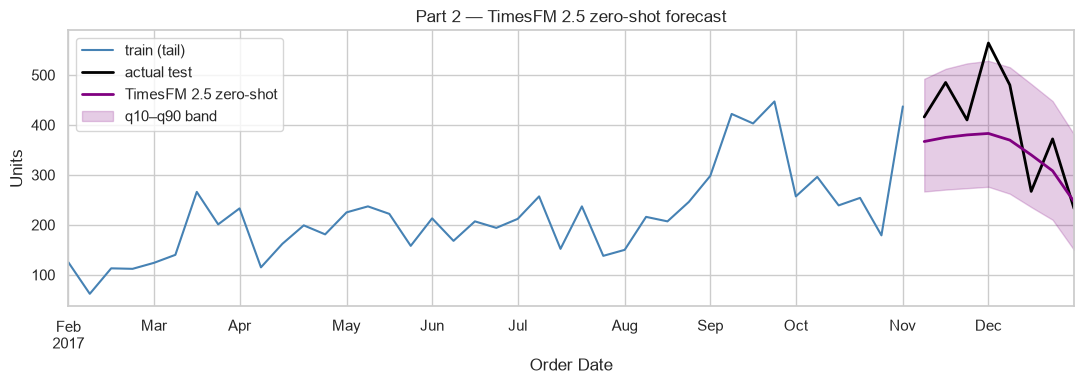

TimesFM holdout metrics: {'MAE': 78.8434, 'RMSE': 93.5035, 'MAPE': 18.3943, 'MASE': 0.9899}


In [10]:
torch.set_float32_matmul_precision("high")

print("Loading TimesFM 2.5 200M (PyTorch) from Hugging Face…")
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")
context_len = int(min(len(y_train), 1024))
tfm.compile(
    timesfm.ForecastConfig(
        max_context=context_len,
        max_horizon=H,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
        per_core_batch_size=32,
    )
)

context = y_train.values.astype(np.float32)
point, quantiles = tfm.forecast(horizon=H, inputs=[context])
# point: (1, H); quantiles: (1, H, 10) — idx1=q10, idx5=q50, idx9=q90
tfm_point = np.clip(point[0], 0, None)
tfm_lo = quantiles[0, :, 1]
tfm_hi = quantiles[0, :, 9]
tfm_fc = pd.Series(tfm_point, index=y_test.index, name="timesfm")
tfm_lo_s = pd.Series(tfm_lo, index=y_test.index)
tfm_hi_s = pd.Series(tfm_hi, index=y_test.index)

print(f"Context length used: {len(context)} (max_context={context_len})")
print(f"TimesFM point forecast (first 5): {tfm_fc.head().round(1).tolist()}")

fig, ax = plt.subplots(figsize=(11, 4))
y_train.iloc[-min(40, len(y_train)) :].plot(ax=ax, label="train (tail)", color="steelblue")
y_test.plot(ax=ax, label="actual test", color="black", lw=2)
tfm_fc.plot(ax=ax, label="TimesFM 2.5 zero-shot", color="purple", lw=2)
ax.fill_between(y_test.index, tfm_lo_s, tfm_hi_s, color="purple", alpha=0.2, label="q10–q90 band")
ax.set_title("Part 2 — TimesFM 2.5 zero-shot forecast")
ax.set_ylabel("Units")
ax.legend()
show_plot()

metrics_tfm = forecast_metrics(y_test.values, tfm_fc.values, y_train.values, mase_period)
print("TimesFM holdout metrics:", {k: round(v, 4) for k, v in metrics_tfm.items()})

## 8. Side-by-side comparison

Same holdout, same metrics (MAE, RMSE, MAPE, MASE). Lower is better for all
four as defined here.

=== Holdout metrics (identical definitions) ===


,MAE,RMSE,MAPE,MASE
Native (ets),104.8437,119.4498,26.6113,1.3164
TimesFM 2.5 zero-shot,78.8434,93.5035,18.3943,0.9899



Lower MASE wins on this holdout → TimesFM 2.5 zero-shot
Native MASE=1.3164 vs TimesFM MASE=0.9899


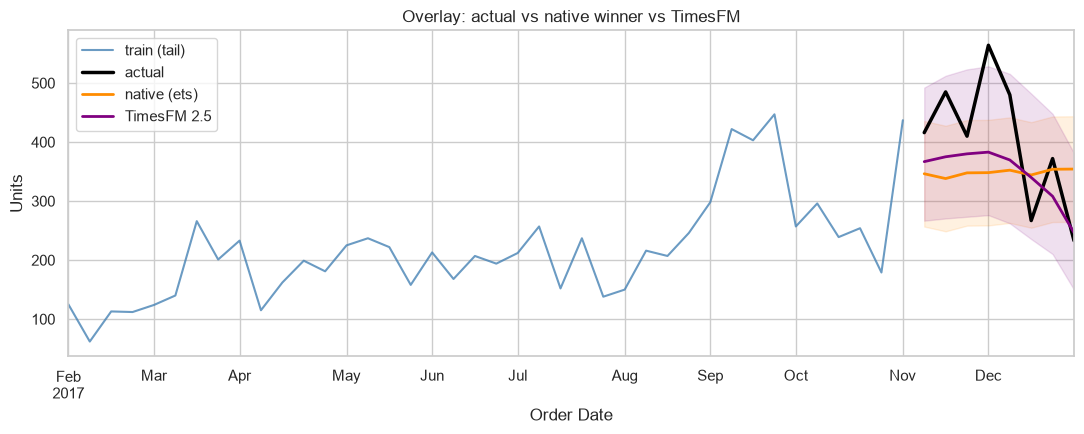


=== Why this result is plausible ===
TimesFM 2.5 zero-shot achieved lower MASE than the native reimplementation of ets. Foundation models can transfer patterns from large multi-series pretraining when local seasonality is weak, noisy, or when the classical model is misspecified. History was still provided as context (len=201).


In [11]:
comparison = pd.DataFrame(
    {
        f"Native ({winner_id})": metrics_native,
        "TimesFM 2.5 zero-shot": metrics_tfm,
    }
).T
comparison = comparison[["MAE", "RMSE", "MAPE", "MASE"]]
print("=== Holdout metrics (identical definitions) ===")
display(comparison.round(4))

best_mase_model = comparison["MASE"].idxmin()
print(f"\nLower MASE wins on this holdout → {best_mase_model}")
print(
    f"Native MASE={metrics_native['MASE']:.4f} vs TimesFM MASE={metrics_tfm['MASE']:.4f}"
)

fig, ax = plt.subplots(figsize=(11, 4.5))
y_train.iloc[-min(40, len(y_train)) :].plot(ax=ax, label="train (tail)", color="steelblue", alpha=0.8)
y_test.plot(ax=ax, label="actual", color="black", lw=2.5)
native_fc.plot(ax=ax, label=f"native ({winner_id})", color="darkorange", lw=2)
tfm_fc.plot(ax=ax, label="TimesFM 2.5", color="purple", lw=2)
ax.fill_between(y_test.index, native_lo_s, native_hi_s, color="darkorange", alpha=0.12)
ax.fill_between(y_test.index, tfm_lo_s, tfm_hi_s, color="purple", alpha=0.12)
ax.set_title("Overlay: actual vs native winner vs TimesFM")
ax.set_ylabel("Units")
ax.legend()
show_plot()

# Dynamic interpretation
native_better = metrics_native["MASE"] < metrics_tfm["MASE"]
print("\n=== Why this result is plausible ===")
if native_better:
    print(
        f"The PyCaret-selected native model ({winner_id} → {native_label}) achieved "
        f"lower MASE on this Superstore {GRAIN} series. Classical models can exploit "
        f"domain-specific seasonality/trend when the series is relatively regular and "
        f"the train window is long enough for parameter estimation "
        f"(n_train={len(y_train)}, H={H}). TimesFM still used the full train context "
        f"zero-shot, but without Superstore-specific coefficient fitting."
    )
else:
    print(
        f"TimesFM 2.5 zero-shot achieved lower MASE than the native reimplementation of "
        f"{winner_id}. Foundation models can transfer patterns from large multi-series "
        f"pretraining when local seasonality is weak, noisy, or when the classical model "
        f"is misspecified. History was still provided as context (len={len(y_train)})."
    )

## 9. Inventory-planning takeaway

We close with a **directional** planning read — not a formal safety-stock formula.

In [12]:
mean_fc_native = float(native_fc.mean())
mean_fc_tfm = float(tfm_fc.mean())
mean_actual = float(y_test.mean())
# Prefer the lower-MASE model for planning narrative; still show both bands
if native_better:
    plan_fc, plan_lo, plan_hi, plan_name = native_fc, native_lo_s, native_hi_s, f"native/{winner_id}"
else:
    plan_fc, plan_lo, plan_hi, plan_name = tfm_fc, tfm_lo_s, tfm_hi_s, "TimesFM 2.5"

avg_point = float(plan_fc.mean())
avg_lo = float(plan_lo.mean())
avg_hi = float(plan_hi.mean())
band_width = avg_hi - avg_lo

print("=== Inventory-facing summary (from this run) ===")
print(f"Grain: {GRAIN} | holdout periods: {H}")
print(f"Actual mean demand in holdout: {mean_actual:.1f} units / period")
print(f"Preferred model for narrative: {plan_name}")
print(f"  mean point forecast: {avg_point:.1f}")
print(f"  mean lower band:     {avg_lo:.1f}")
print(f"  mean upper band:     {avg_hi:.1f}")
print(f"  mean band width:     {band_width:.1f}")
print()
print(
    f"If you plan replenishment around the point forecast (~{avg_point:.0f} units per {GRAIN[:-2] if GRAIN.endswith('ly') else GRAIN}), "
    f"the uncertainty band (~{avg_lo:.0f}–{avg_hi:.0f}) is a practical envelope for a "
    f"service-minded buffer: covering toward the upper end reduces stockout risk when "
    f"demand spikes, at the cost of extra on-hand inventory. "
    f"Compared with a pure point order of {avg_point:.0f}, targeting closer to "
    f"{avg_hi:.0f} is the more conservative (higher service level) posture suggested by "
    f"this model's predictive distribution — not a full EOQ/safety-stock calculation, "
    f"but a directionally useful reorder signal from the forecast + interval."
)
print()
print("Metric recap:")
display(comparison.round(4))
print(f"\nGranularity decision was: {decision_reason}")
print(f"PyCaret winner: {winner_id} | Native label: {native_label}")
print("Notebook 01 complete.")

=== Inventory-facing summary (from this run) ===
Grain: weekly | holdout periods: 8
Actual mean demand in holdout: 403.4 units / period
Preferred model for narrative: TimesFM 2.5
  mean point forecast: 346.1
  mean lower band:     243.1
  mean upper band:     485.4
  mean band width:     242.2

If you plan replenishment around the point forecast (~346 units per week), the uncertainty band (~243–485) is a practical envelope for a service-minded buffer: covering toward the upper end reduces stockout risk when demand spikes, at the cost of extra on-hand inventory. Compared with a pure point order of 346, targeting closer to 485 is the more conservative (higher service level) posture suggested by this model's predictive distribution — not a full EOQ/safety-stock calculation, but a directionally useful reorder signal from the forecast + interval.

Metric recap:


,MAE,RMSE,MAPE,MASE
Native (ets),104.8437,119.4498,26.6113,1.3164
TimesFM 2.5 zero-shot,78.8434,93.5035,18.3943,0.9899



Granularity decision was: Daily series has 15.2% zero-demand days and CV=0.98 vs weekly CV=0.57. Weekly aggregation is more stable for inventory planning.
PyCaret winner: ets | Native label: statsmodels ExponentialSmoothing (seasonal=True)
Notebook 01 complete.
